# Titanic Dataset - Mini Exploratory Data Analysis (EDA)

## Data Science & Analysis with Python Internship – Task 3

### Objective

The objective of this project is to perform a Mini Exploratory Data Analysis (EDA) on the Titanic dataset. The analysis includes data cleaning, exploration of survival patterns, and visualization of insights using Python libraries such as Pandas, Matplotlib, and Seaborn.

# Import required libraries

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the Dataset

The Titanic dataset is loaded into a Pandas DataFrame for further exploration and analysis.


In [14]:
df = pd.read_csv("../data/Titanic-Dataset.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## Observation

The dataset has been loaded successfully. The first five rows provide an overview of the passenger information, including demographic details, ticket information, and survival status.

# Dataset Information

This step provides information about the dataset, including the number of rows and columns, data types, and missing values.

In [15]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 118.9 KB


## Observation

The dataset contains **891 passenger records** and **12 columns**, consisting of both numerical and categorical features.

- Numerical columns include **PassengerId, Survived, Pclass, Age, SibSp, Parch,** and **Fare**.
- Categorical columns include **Name, Sex, Ticket, Cabin,** and **Embarked**.
- Missing values are present in the **Age**, **Cabin**, and **Embarked** columns, which need to be handled before performing exploratory data analysis.

# Statistical Summary

In this step, we generate descriptive statistics for the numerical columns in the Titanic dataset. The summary provides useful information such as the count, mean, standard deviation, minimum, maximum, and quartile values, helping us understand the overall distribution of the data.

In [16]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


## Observation

The statistical summary provides important insights into the numerical features of the Titanic dataset.

- The dataset contains **891 passenger records**.
- The average passenger age is approximately **29.70 years**, with ages ranging from **0.42 years** to **80 years**.
- The average passenger fare is **32.20**, with fares ranging from **0** to **512.33**, indicating a wide variation in ticket prices.
- The average passenger class (**Pclass**) is **2.31**, showing that most passengers belonged to the Second and Third Classes.
- The average number of siblings/spouses (**SibSp**) per passenger is **0.52**, while the average number of parents/children (**Parch**) is **0.38**, indicating that most passengers traveled alone or with a small family.
- The statistical summary provides a better understanding of the dataset before performing data cleaning and exploratory data analysis.

 # Check Missing Values

In this step, we identify the number of missing values present in each column of the Titanic dataset. Detecting missing values is an important step in data preprocessing, as it helps determine the appropriate cleaning techniques before performing exploratory data analysis.

In [17]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

## Observation

The dataset contains missing values in three columns:

- **Age** has **177** missing values.
- **Cabin** has **687** missing values.
- **Embarked** has **2** missing values.

Since these missing values can affect the analysis, appropriate data cleaning techniques will be applied in the next step. The **Age** column will be filled using the mean value, the **Embarked** column will be filled using the most frequent value (mode), and the **Cabin** column will be removed because it contains a large number of missing values.

# Data Cleaning

In this step, the missing values in the dataset are handled to improve data quality before performing Exploratory Data Analysis (EDA).

The following preprocessing techniques are applied:

- Missing values in the **Age** column are replaced with the **mean** age.
- The **Cabin** column is removed because it contains a large number of missing values.
- Missing values in the **Embarked** column are replaced with the **most frequent (mode)** value.

These steps ensure that the dataset is complete and suitable for further analysis.

In [18]:
# Fill missing values in Age with mean
df["Age"] = df["Age"].fillna(df["Age"].mean())

# Fill missing values in Embarked with mode
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

# Drop Cabin column
df.drop("Cabin", axis=1, inplace=True)

# Verify missing values
df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

## Observation

All missing values have been successfully handled.

- Missing values in the **Age** column were replaced with the **mean** age.
- The **Cabin** column was removed because it contained a large number of missing values.
- Missing values in the **Embarked** column were replaced with the **most frequent embarkation port**.

After applying these preprocessing techniques, all remaining columns contain complete data with no missing values. The dataset is now clean and ready for Exploratory Data Analysis (EDA).

# Analysis 1: Survival Rate by Age Group

In this analysis, passengers are divided into different age groups to examine how the survival rate varies across different age categories. This helps identify whether age influenced the chances of survival during the Titanic disaster.

In [19]:
# Create age groups
df["AgeGroup"] = pd.cut(
    df["Age"],
    bins=[0, 12, 18, 35, 60, 100],
    labels=["Child", "Teen", "Young Adult", "Adult", "Senior"]
)

# Calculate survival rate by age group
survival_by_age = df.groupby("AgeGroup")["Survived"].mean() * 100

print(survival_by_age)

AgeGroup
Child          57.971014
Teen           42.857143
Young Adult    35.327103
Adult          40.000000
Senior         22.727273
Name: Survived, dtype: float64


## Observation

The survival rate varied across different age groups.

- **Children** had the highest survival rate at **57.97%**, indicating they had the greatest chance of survival.
- **Adults** had a survival rate of **40.00%**, followed closely by **Teenagers** with **42.86%**.
- **Young Adults** had a survival rate of **35.33%**, which was lower than that of children and adults.
- **Senior** passengers had the lowest survival rate at **22.73%**.

These results suggest that age influenced survival during the Titanic disaster, with children having the highest survival chances and senior passengers the lowest.

# Analysis 2: Survival Rate by Embarkation Port

In this analysis, we examine the survival rate of passengers based on their embarkation port. This helps determine whether the port from which passengers boarded the Titanic had any relationship with their survival chances.

In [20]:
# Survival rate by embarkation port
survival_by_port = df.groupby("Embarked")["Survived"].mean() * 100

print(survival_by_port)

Embarked
C    55.357143
Q    38.961039
S    33.900929
Name: Survived, dtype: float64


## Observation

The survival rate varied across the three embarkation ports.

- Passengers who boarded at **Cherbourg (C)** had the highest survival rate at **55.36%**.
- Passengers who boarded at **Queenstown (Q)** had a survival rate of **38.96%**.
- Passengers who boarded at **Southampton (S)** had the lowest survival rate at **33.90%**.

These results indicate that the embarkation port was associated with different survival rates, with passengers embarking from Cherbourg having the highest likelihood of survival.

# Analysis 3: Survival Rate by Family Size

In this analysis, we calculate the family size of each passenger by adding the number of siblings/spouses (**SibSp**) and parents/children (**Parch**). We then examine how the survival rate varies with family size to understand whether travelling alone or with family influenced the chances of survival.

In [21]:
# Create a new column for Family Size
df["FamilySize"] = df["SibSp"] + df["Parch"]

# Calculate survival rate by family size
survival_by_family = df.groupby("FamilySize")["Survived"].mean() * 100

print(survival_by_family)

FamilySize
0     30.353818
1     55.279503
2     57.843137
3     72.413793
4     20.000000
5     13.636364
6     33.333333
7      0.000000
10     0.000000
Name: Survived, dtype: float64


## Observation

The survival rate varied considerably with family size.

- Passengers travelling with a **family size of 3** had the highest survival rate at **72.41%**.
- Family sizes of **2 (57.84%)** and **1 (55.28%)** also showed relatively high survival rates.
- Passengers travelling **alone (Family Size = 0)** had a survival rate of **30.35%**.
- Larger family sizes (**4 and above**) generally had much lower survival rates, with family sizes **7** and **10** having **0%** survival.

These findings suggest that passengers travelling with small families had better chances of survival, while those travelling alone or in very large families had lower survival rates.

# Visualization 1: Age Distribution

This histogram displays the distribution of passenger ages in the Titanic dataset. It helps us understand the age composition of the passengers and identify the most common age groups.

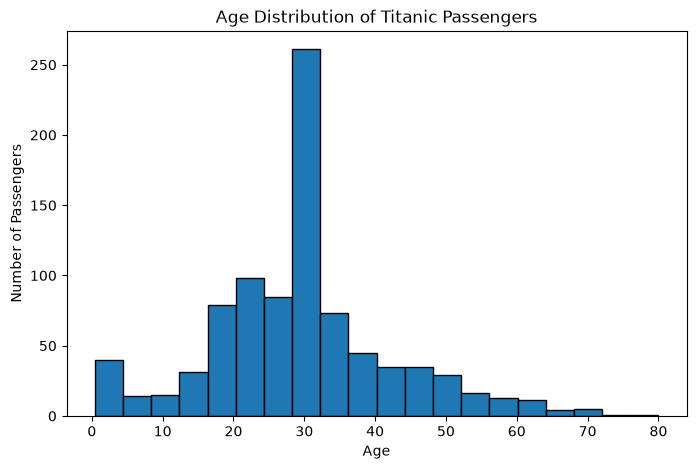

In [22]:
plt.figure(figsize=(8,5))

plt.hist(df["Age"], bins=20, edgecolor="black")

plt.title("Age Distribution of Titanic Passengers")
plt.xlabel("Age")
plt.ylabel("Number of Passengers")

plt.show()

## Observation

The histogram shows that the majority of passengers were between **20 and 35 years** of age, with the highest concentration around **30 years**. There were relatively fewer children (below 15 years) and senior passengers (above 60 years). The age distribution is slightly right-skewed, indicating that most passengers were young adults, while older passengers formed a much smaller proportion of the dataset.

# Visualization 2: Correlation Heatmap

A correlation heatmap is used to visualize the relationships between numerical features in the Titanic dataset. Correlation values range from **-1** to **1**, where:

- **1** indicates a strong positive correlation.
- **-1** indicates a strong negative correlation.
- **0** indicates no correlation.

This visualization helps identify which numerical features are most strongly related to passenger survival.

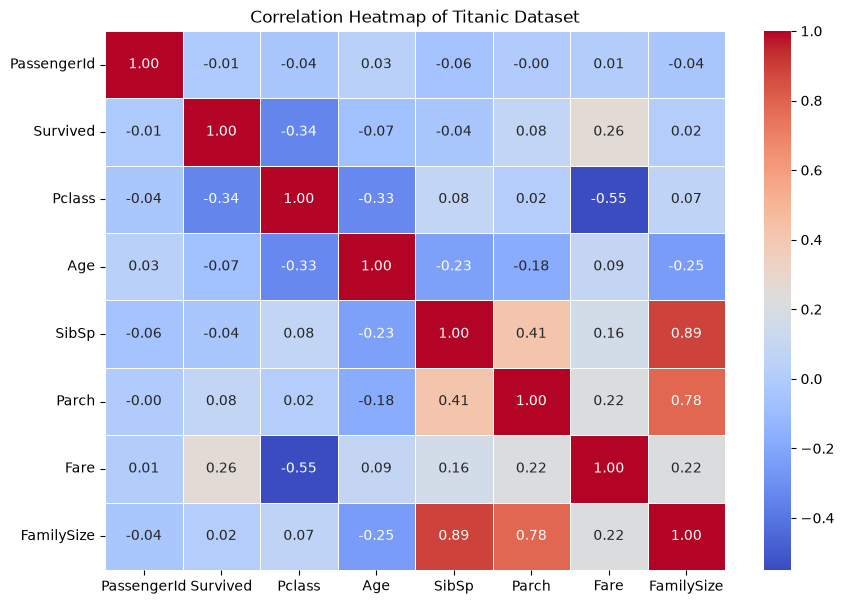

In [23]:
# Select only numerical columns
numeric_df = df.select_dtypes(include=["number"])

# Plot correlation heatmap
plt.figure(figsize=(10, 7))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Heatmap of Titanic Dataset")

plt.show()

## Observation

The correlation heatmap illustrates the relationships between the numerical features in the Titanic dataset.

- **Passenger Class (Pclass)** has a **moderate negative correlation (-0.34)** with **Survived**, indicating that passengers in higher classes were more likely to survive.
- **Fare** has a **positive correlation (0.26)** with **Survived**, suggesting that passengers who paid higher fares had better survival chances.
- **SibSp** and **FamilySize** have a **strong positive correlation (0.89)** because family size is calculated using the number of siblings/spouses and parents/children.
- **Parch** also has a **strong positive correlation (0.78)** with **FamilySize**.
- **Pclass** and **Fare** show a **strong negative correlation (-0.55)**, indicating that passengers in higher classes generally paid higher fares.
- Most of the remaining features have weak correlations with survival, suggesting that no single numerical feature alone strongly determines passenger survival.

Overall, the heatmap provides valuable insights into the relationships among numerical variables and highlights **Passenger Class** and **Fare** as important factors associated with survival.

# Visualization 3: Survival Rate by Family Size

This bar chart illustrates the survival rate for passengers based on their family size. It helps identify whether travelling alone, with a small family, or with a large family influenced the likelihood of survival during the Titanic disaster.

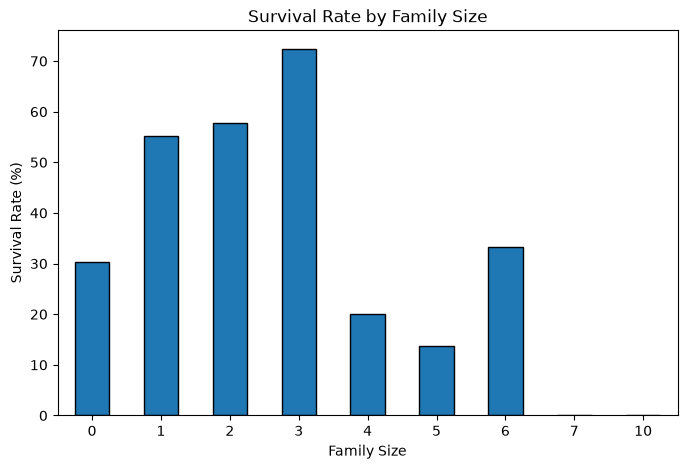

In [24]:
plt.figure(figsize=(8,5))

survival_by_family.plot(
    kind="bar",
    edgecolor="black"
)

plt.title("Survival Rate by Family Size")
plt.xlabel("Family Size")
plt.ylabel("Survival Rate (%)")
plt.xticks(rotation=0)

plt.show()

## Observation

The bar chart shows that survival rates varied significantly with family size.

- Passengers travelling with a **family size of 3** had the highest survival rate, at approximately **72.41%**.
- Family sizes of **1** and **2** also had relatively high survival rates, exceeding **55%**.
- Passengers travelling **alone (Family Size = 0)** had a lower survival rate of approximately **30.35%**.
- Larger family sizes (**4, 5, 7, and 10**) had much lower survival rates, with family sizes **7** and **10** showing **0%** survival.

These results suggest that passengers travelling with **small families** had better chances of survival than those travelling alone or with very large families.

## Conclusion

This Mini Exploratory Data Analysis (EDA) on the Titanic dataset provided valuable insights into the factors that influenced passenger survival.

The dataset was successfully cleaned by handling missing values and removing unnecessary data, making it suitable for analysis. Exploratory analysis revealed that:

- **Children** had the highest survival rate, while **senior passengers** had the lowest.
- Passengers who boarded at **Cherbourg (C)** experienced the highest survival rate compared to those boarding at other ports.
- Passengers travelling with **small families** had better chances of survival than those travelling alone or with large families.
- The correlation analysis indicated that **Passenger Class (Pclass)** and **Fare** were among the numerical features most closely associated with survival.
- The visualizations effectively illustrated passenger age distribution, relationships between numerical variables, and survival trends based on family size.

Overall, this project strengthened my understanding of **data preprocessing**, **exploratory data analysis (EDA)**, **data visualization**, and **drawing meaningful insights from real-world datasets** using Python, Pandas, Matplotlib, and Seaborn.